## 1. Global Assumptions

In [1]:

import pandas as pd
import numpy as np

years = [2026,2027,2028]


## 2. Scenario Engine

In [4]:

def build_scenario_table(growth, base_mm, base_ma):
    df = pd.DataFrame(index=[
        "Clients_MM","Clients_MA","Clients_total",
        "AUM_MM","AUM_MA","AUM_total",
        "Revenue_commission","Revenue_fixed","Revenue_total"
    ], columns=years)
    mm=[base_mm]; ma=[base_ma]
    for _ in range(1,len(years)):
        mm.append(mm[-1]*(1+growth))
        ma.append(ma[-1]*(1+growth*0.8))
    df.loc["Clients_MM"]=mm; df.loc["Clients_MA"]=ma
    df.loc["Clients_total"]=np.array(mm)+np.array(ma)
    df.loc["AUM_MM"]=df.loc["Clients_MM"]*0.55
    df.loc["AUM_MA"]=df.loc["Clients_MA"]*3.8
    df.loc["AUM_total"]=df.loc["AUM_MM"]+df.loc["AUM_MA"]
    df.loc["Revenue_commission"]=df.loc["AUM_total"]*0.01
    df.loc["Revenue_fixed"]=df.loc["Clients_total"]*500
    df.loc["Revenue_total"]=df.loc["Revenue_commission"]+df.loc["Revenue_fixed"]
    return df

scenario_tables={
    "accelerated": build_scenario_table(0.35,700000,200000),
    "base": build_scenario_table(0.22,700000,200000),
    "stress": build_scenario_table(0.12,700000,200000)
}


## 3. Cohort Engine

In [5]:

retention_curve=[1.0,0.68,0.52]
arpu_curve=[3400,3600,3900]

def build_cohort_revenue_matrix(scenario_name, scenario_table, retention, arpu):
    years=[2026,2027,2028]
    matrix=pd.DataFrame(index=years, columns=years, dtype=float)
    cohorts={y: scenario_table.loc["Clients_total",y] for y in years}
    for cy in years:
        for ry in years:
            ly=ry-cy
            if ly<0 or ly>=len(retention):
                matrix.loc[cy,ry]=0
            else:
                matrix.loc[cy,ry]=cohorts[cy]*retention[ly]*arpu[ly]
    return matrix

cohort_matrices={s:build_cohort_revenue_matrix(
    s,scenario_tables[s],retention_curve,arpu_curve) for s in scenario_tables}


## 4. LTV Engine

In [6]:

def calc_ltv(retention,arpu):
    return sum(retention[i]*arpu[i] for i in range(len(retention)))

ltv_by_scenario={s:calc_ltv(retention_curve,arpu_curve) for s in scenario_tables}


## 5. Visualization Suite

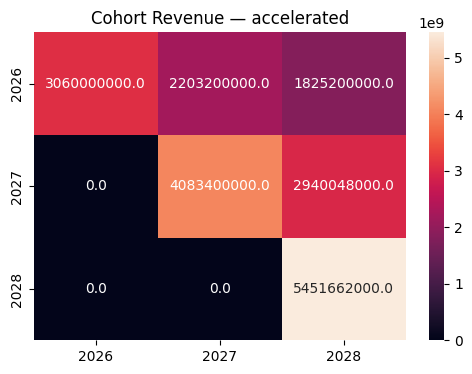

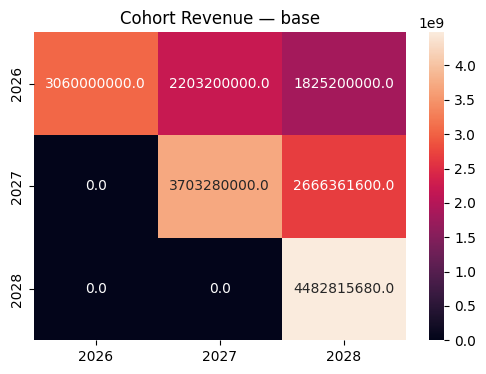

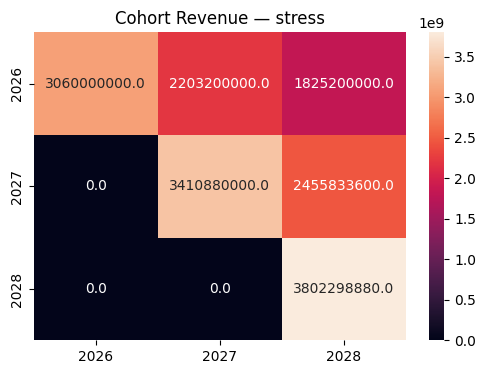

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

for scen,df in cohort_matrices.items():
    plt.figure(figsize=(6,4))
    sns.heatmap(df,annot=True,fmt=".1f")
    plt.title(f"Cohort Revenue — {scen}")
    plt.show()


## 6. Waterfall

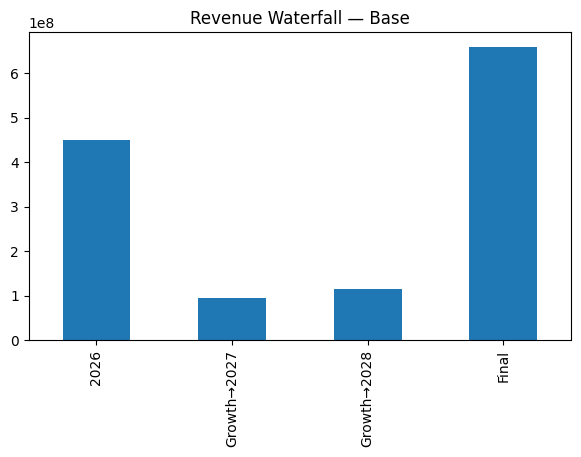

In [8]:

base=scenario_tables["base"]
rev=base.loc["Revenue_total"]

water=pd.Series({
    "2026":rev[2026],
    "Growth→2027":rev[2027]-rev[2026],
    "Growth→2028":rev[2028]-rev[2027],
    "Final":rev[2028]
})
plt.figure(figsize=(7,4))
water.plot(kind="bar")
plt.title("Revenue Waterfall — Base")
plt.show()


## 7. AUM Dynamics

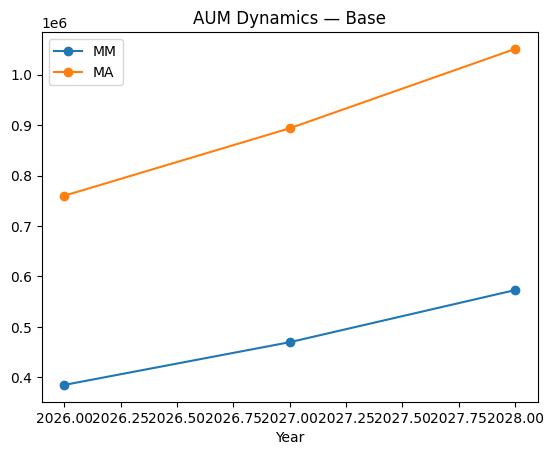

In [9]:

aum = pd.DataFrame({
    "Year":years,
    "MM": scenario_tables["base"].loc["AUM_MM",years].values,
    "MA": scenario_tables["base"].loc["AUM_MA",years].values
}).set_index("Year")
aum.plot(marker="o")
plt.title("AUM Dynamics — Base")
plt.show()


## 8. Revenue Breakdown

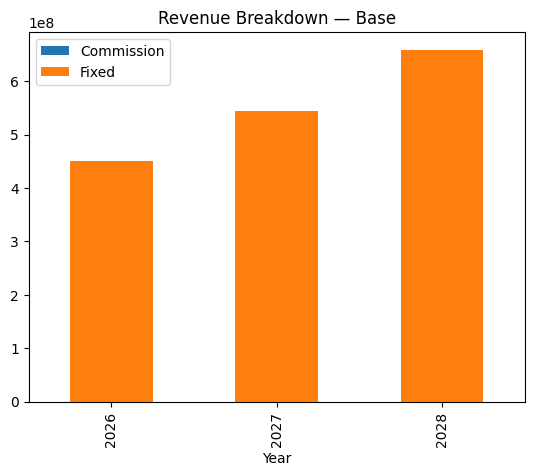

In [10]:

rev_df = pd.DataFrame({
    "Year":years,
    "Commission":scenario_tables["base"].loc["Revenue_commission",years].values,
    "Fixed":scenario_tables["base"].loc["Revenue_fixed",years].values,
})
rev_df.set_index("Year").plot(kind="bar",stacked=True)
plt.title("Revenue Breakdown — Base")
plt.show()


## 9. Summary Tables

In [11]:

summary=pd.DataFrame({
    "Scenario":list(ltv_by_scenario.keys()),
    "LTV":list(ltv_by_scenario.values())
})
summary


,Scenario,LTV
0,accelerated,7876.0
1,base,7876.0
2,stress,7876.0
